# Week 2 Bonus: The Deep Learning Model

**A deeper neural network built with Keras, the tool used in real AI labs.**

*Author: The Genius Project Year 3*

---

### What you will build
- A deep learning model built layer by layer with TensorFlow and Keras.
- Win chances and a predicted scoreline for each upcoming fixture.
- A first look at the exact tools professional AI engineers use every day.

### The big idea, in one breath
Deep learning stacks several layers of switches and trains them with many small steps. It is the same family of tools behind image recognition and chatbots, here pointed at football.

> This notebook uses a realistic teaching dataset. The numbers are believable and
> the patterns are real, but they are not official statistics. The goal is to learn
> how the models think, not to run a betting shop.

**Football note:** we call the sport *football* (some countries call it soccer).
Every stat is explained in plain words below, so you do not need to be a fan to follow along.

> **Heads up:** this bonus notebook uses TensorFlow. If it is not installed, run the next cell once. It can take a minute. Everything else in Week 2 works without it.

In [1]:
# Run once if needed, then restart is not required.
# import sys; !{sys.executable} -m pip install --quiet tensorflow

### The stats we use, in plain words

| Column | What it means |
| --- | --- |
| `team` | The national team, for example Brazil or Japan. |
| `confederation` | The region a team belongs to. UEFA is Europe, CONMEBOL is South America, CAF is Africa, AFC is Asia, CONCACAF is North and Central America. |
| `fifa_ranking` | The team's position on the official world ladder. 1 is the best. A smaller number is better. |
| `fifa_points` | The score behind the ranking. More points means a stronger team. |
| `elo_rating` | Another strength score, borrowed from chess. Higher is stronger. |
| `world_cup_titles` | How many times the team has won the World Cup. |
| `avg_goals_scored` | Goals the team scores in a typical match. This is their attack. Higher is better. |
| `avg_goals_conceded` | Goals the team lets in during a typical match. This is their defence. Lower is better. |
| `possession_pct` | The share of the match, out of 100, that the team keeps the ball. More possession usually means more control. |
| `pass_accuracy_pct` | Out of every 100 passes, how many reach a team mate. |
| `shots_per_game` | How many attempts at goal the team takes in a match. |
| `shots_on_target_per_game` | Shots that were heading into the net, whether or not they scored. |
| `big_chances_per_game` | Clear chances to score in a match, the kind a player is expected to finish. |
| `clean_sheet_pct` | Out of 100 matches, how many the team finishes without letting in a single goal. |
| `win_rate_last10` | The share of the last 10 matches the team won, from 0 to 1. 0.7 means they won 7 of 10. |
| `form_points_last5` | Points from the last 5 matches. A win is 3 points, a draw is 1, a loss is 0. The most is 15. |
| `squad_avg_age` | The average age of the players in the squad. |
| `squad_value_million_eur` | The total transfer value of the squad, in millions of euros. A rough measure of talent. |
| `top_league_player_share` | The share of players, from 0 to 1, who play for clubs in the strongest leagues. |
| `set_piece_goal_pct` | Out of 100 goals, how many come from free kicks and corners rather than open play. |
| `key_player_injuries` | How many important players are currently injured. |
| `is_2026_host` | 1 if the team is hosting the 2026 World Cup (USA, Canada, Mexico), otherwise 0. |

You do not have to memorise these. Glance back whenever a column name shows up.

### Step 1: Load the data and build the numbers

In [2]:
import pandas as pd
import numpy as np

# 1. Load the three tables.
teams = pd.read_csv("data/teams.csv")
matches = pd.read_csv("data/matches.csv")
upcoming = pd.read_csv("data/upcoming_matches.csv")

# 2. The numbers we will feed the model for each team.
#    Think of these as the "stats card" for a team.
TEAM_STATS = [
    "fifa_points", "elo_rating", "avg_goals_scored", "avg_goals_conceded",
    "possession_pct", "pass_accuracy_pct", "shots_on_target_per_game",
    "big_chances_per_game", "clean_sheet_pct", "win_rate_last10",
    "form_points_last5", "squad_value_million_eur", "top_league_player_share",
    "key_player_injuries",
]

# 3. A helper that takes a match (team_a vs team_b) and returns one flat row
#    of numbers: team A's stats, team B's stats, and the gap between them.
stats_by_team = teams.set_index("team")

def build_features(team_a, team_b):
    a = stats_by_team.loc[team_a, TEAM_STATS]
    b = stats_by_team.loc[team_b, TEAM_STATS]
    row = {}
    for stat in TEAM_STATS:
        row[f"{stat}_a"] = a[stat]      # team A value
        row[f"{stat}_b"] = b[stat]      # team B value
        row[f"{stat}_diff"] = a[stat] - b[stat]   # the gap (A minus B)
    return row

# 4. Turn every historical match into a row of features.
feature_rows = [build_features(r.team_a, r.team_b) for r in matches.itertuples()]
X_full = pd.DataFrame(feature_rows)

# 5. For the model we keep the GAP columns (team A value minus team B value).
#    These are the easiest to read: a positive weight on a gap means
#    "when team A has more of this than team B, team A is more likely to win."
DIFF_COLS = [c for c in X_full.columns if c.endswith("_diff")]
X = X_full[DIFF_COLS]

# 5. The answer we want the model to learn (the "target").
#    0 = team A won, 1 = draw, 2 = team B won.
def result_code(row):
    if row.winner == row.team_a:
        return 0
    if row.winner == "Draw":
        return 1
    return 2

y = matches.apply(result_code, axis=1)
LABELS = {0: "Team A win", 1: "Draw", 2: "Team B win"}

print("Feature table shape:", X.shape)
print("Example features for the first match:")
X.head(1).T.head(6)


Feature table shape: (900, 14)
Example features for the first match:


,0
fifa_points_diff,12.50
elo_rating_diff,31.00
avg_goals_scored_diff,0.02
avg_goals_conceded_diff,0.28
possession_pct_diff,6.40
pass_accuracy_pct_diff,3.10


### Step 2: The football maths for expected scores

In [3]:
from math import exp, factorial

def poisson(k, mean):
    "Chance of exactly k goals when a team averages `mean` goals."
    return (mean ** k) * exp(-mean) / factorial(k)

def expected_scoreline(team_a, team_b, max_goals=8):
    """Predict goals for each team and the chance of each result.

    We blend a team's attack with the other team's defence. If A usually
    scores 2.0 and B usually lets in 1.4, A's expected goals sit between them.
    """
    a = stats_by_team.loc[team_a]
    b = stats_by_team.loc[team_b]
    xg_a = 0.5 * (a["avg_goals_scored"] + b["avg_goals_conceded"])
    xg_b = 0.5 * (b["avg_goals_scored"] + a["avg_goals_conceded"])

    p_a = p_draw = p_b = 0.0
    for ga in range(max_goals + 1):
        for gb in range(max_goals + 1):
            p = poisson(ga, xg_a) * poisson(gb, xg_b)
            if ga > gb:
                p_a += p
            elif ga == gb:
                p_draw += p
            else:
                p_b += p
    return {
        "expected_goals_a": round(xg_a, 2),
        "expected_goals_b": round(xg_b, 2),
        "predicted_score": f"{round(xg_a)} - {round(xg_b)}",
        "score_win_prob_a": round(p_a, 3),
        "score_draw_prob": round(p_draw, 3),
        "score_win_prob_b": round(p_b, 3),
    }


### Step 3: Prepare the data for deep learning

Deep networks want scaled inputs and a fixed set of answer classes. We scale the stats and split into practice and test sets.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_all = scaler.fit_transform(X)
y_all = y.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all)
print("Ready. Inputs per match:", X_train.shape[1])

Ready. Inputs per match: 14


### Step 4: Build the network layer by layer

Each `Dense` layer is a wall of switches. `relu` lets the network bend and learn curves. The last layer has 3 outputs, one per result, turned into probabilities by `softmax`.

In [5]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # keep TensorFlow's start up messages quiet
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

deep = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(48, activation="relu"),
    layers.Dropout(0.2),                      # randomly rests switches to avoid memorising
    layers.Dense(24, activation="relu"),
    layers.Dense(3, activation="softmax"),    # 3 results: A win, draw, B win
])

deep.compile(optimizer="adam",
             loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])
deep.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 48)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,971 (7.70 KB)

 Trainable params: 1,971 (7.70 KB)

 Non-trainable params: 0 (0.00 B)

### Step 5: Train the model

One `epoch` is one pass through the practice matches. We watch the test accuracy climb, then level off. That plateau is the model saying it has learned what it can.

In [6]:
history = deep.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40, batch_size=32, verbose=0)

final_acc = history.history["val_accuracy"][-1]
print("Final accuracy on hidden matches:", round(final_acc, 3))

Final accuracy on hidden matches: 0.507


### Step 6: Watch it learn

This chart shows accuracy rising over the epochs. Real AI teams stare at plots like this all day.

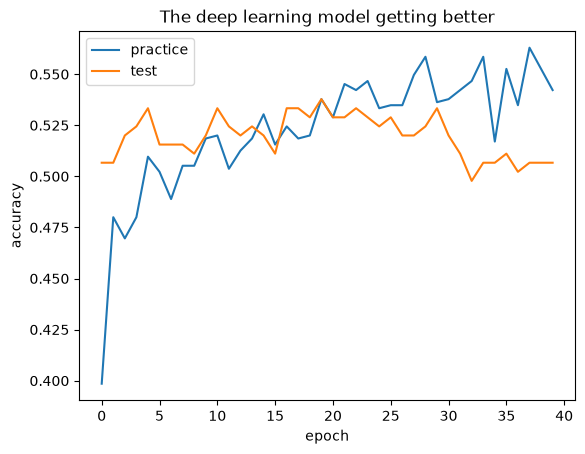

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="practice")
plt.plot(history.history["val_accuracy"], label="test")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("The deep learning model getting better")
plt.show()

### Step 7: Predict the upcoming World Cup matches

In [8]:
for m in upcoming.itertuples():
    feats = scaler.transform(pd.DataFrame([build_features(m.team_a, m.team_b)])[X.columns])
    probs = deep.predict(feats, verbose=0)[0]
    score = expected_scoreline(m.team_a, m.team_b)
    print(f"{m.team_a} vs {m.team_b}   ({m.stage})")
    print(f"   {m.team_a} win %      {round(float(probs[0])*100,1)}")
    print(f"   draw %              {round(float(probs[1])*100,1)}")
    print(f"   {m.team_b} win %      {round(float(probs[2])*100,1)}")
    print(f"   predicted score     {score['predicted_score']}")
    print(f"   expected goals      {score['expected_goals_a']} - {score['expected_goals_b']}")
    print()

Argentina vs Nigeria   (Group Stage)
   Argentina win %      61.3
   draw %              37.3
   Nigeria win %      1.4
   predicted score     2 - 1
   expected goals      1.76 - 0.9

France vs USA   (Group Stage)
   France win %      65.5
   draw %              32.2
   USA win %      2.3
   predicted score     2 - 1
   expected goals      1.6 - 1.06

Brazil vs Japan   (Group Stage)
   Brazil win %      61.5
   draw %              35.4
   Japan win %      3.1
   predicted score     2 - 1
   expected goals      1.86 - 1.12

England vs Senegal   (Group Stage)
   England win %      67.7
   draw %              28.6
   Senegal win %      3.7
   predicted score     2 - 1
   expected goals      1.68 - 1.0



Spain vs Croatia   (Round of 16)
   Spain win %      52.5
   draw %              33.2
   Croatia win %      14.3
   predicted score     2 - 1
   expected goals      1.56 - 1.23

Portugal vs Mexico   (Round of 16)
   Portugal win %      56.5
   draw %              34.8
   Mexico win %      8.7
   predicted score     2 - 1
   expected goals      1.66 - 1.16

Netherlands vs Morocco   (Quarter Final)
   Netherlands win %      34.3
   draw %              40.8
   Morocco win %      24.9
   predicted score     2 - 1
   expected goals      1.51 - 1.29

Germany vs Uruguay   (Quarter Final)
   Germany win %      38.2
   draw %              39.8
   Uruguay win %      22.0
   predicted score     1 - 1
   expected goals      1.38 - 1.29



### Your turn

1. Change `epochs=40` to `epochs=100`. Does the test accuracy keep rising, or level off?
2. Remove the `Dropout` layer and re-run. Dropout fights memorising. What happens without it?
3. Deep learning shines with huge datasets. We only have a few hundred matches. Write one sentence on why more data would help.

## Submit your prediction

You have trained a model and predicted real fixtures. Now enter your answers
in the Week 2 quiz and prediction page:

**https://beagenius.org/tgp-2026teens-week2/06-quiz-and-predict.html**

Bring three things with you for a match of your choice:

1. The win probability for each team.
2. The predicted scoreline (the expected goals rounded to whole numbers).
3. One sentence on which stat mattered most, in your own words.

Good luck, and trust your numbers.
